# DTW event game (simple mixed-event version)

This notebook implements the simple DTW workflow in
`understanding_dtw/dtw模型学习.md` without a significance threshold.

Key choices in this version:
- Event universe is the 4 major releases: CPI, NFP, PCE, FOMC.
- Matching pool is mixed across these major events (not event-specific).
- For each current game, directly use top-k nearest historical paths.

In [ ]:
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dtaidistance import dtw

pd.set_option("display.width", 160)

## Parameters

In [ ]:
def detect_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    if "__file__" in globals():
        candidates.insert(0, Path(__file__).resolve().parents[1])
    for c in candidates:
        if (c / "data" / "processed").exists() and (c / "notebooks").exists():
            return c
    raise FileNotFoundError("Could not detect repository root containing data/ and notebooks/")


REPO_ROOT = detect_repo_root()
PRICE_FILE = REPO_ROOT / "data" / "processed" / "es_1min_bars_2010_2026.parquet"
EVENT_FILE = REPO_ROOT / "data" / "processed" / "macro_event_calendar_expanded_2010_2026.parquet"

# Mixed major-event pool
EVENT_TYPES = ["CPI", "NFP", "PCE", "FOMC"]

# Around each event timestamp T, create candidate game anchors T0 = T + offset.
EVENT_OFFSETS_MIN = [-30, 0, 30, 60]

# Path used for DTW: [T0, T0+60] sampled every 5 minutes (12 returns).
PATH_MINUTES = 60
PATH_FREQ_MIN = 5

# Label return is from [T0+60, T0+90] (a 30-minute game outcome).
ENTRY_DELAY_MINUTES = 60
HOLD_MINUTES = 30

# DTW / neighbor settings.
DTW_WINDOW_STEPS = 3
K_NEIGHBORS = 15
LOOKBACK_YEARS = 5
MIN_HISTORY = 30
RECENCY_HALFLIFE_DAYS = 365 * 2

NY_TZ = ZoneInfo("America/New_York")

## Load price and event data

In [ ]:
if not PRICE_FILE.exists():
    raise FileNotFoundError(f"price file not found: {PRICE_FILE}")
if not EVENT_FILE.exists():
    raise FileNotFoundError(f"event file not found: {EVENT_FILE}")

price = pd.read_parquet(PRICE_FILE, columns=["close"]).sort_index()
if price.index.tz is None:
    price.index = price.index.tz_localize("UTC")
else:
    price.index = price.index.tz_convert("UTC")
close = price["close"].astype(float)

events = pd.read_parquet(EVENT_FILE)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"], utc=True)
events = events[events["event_type"].isin(EVENT_TYPES)].copy()
events = events.sort_values("timestamp_utc").reset_index(drop=True)

print(f"close rows: {len(close):,}, range: {close.index.min()} -> {close.index.max()}")
print(f"event rows after filter: {len(events):,}")
print(events["event_type"].value_counts())

close rows: 4,811,336, range: 2010-07-01 00:00:00+00:00 -> 2026-06-30 23:59:00+00:00
event rows after filter: 764
event_type
CPI     216
NFP     208
PCE     205
FOMC    135
Name: count, dtype: int64


**Findings:** The major-event filter yields 764 timestamps
(CPI 216, NFP 208, PCE 205, FOMC 135), paired with a 4,811,336-row
1-minute UTC ES close series from 2010-07-01 to 2026-06-30.

## Helper functions

In [ ]:
def zscore(x: np.ndarray) -> np.ndarray:
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-12:
        return np.zeros_like(x)
    return (x - mu) / sd


def dtw_distance_windowed(x: np.ndarray, y: np.ndarray, window: int) -> float:
    """
    Univariate DTW distance using dtaidistance with Sakoe-Chiba window.
    """
    n, m = len(x), len(y)
    if n == 0 or m == 0:
        return np.nan

    w = int(max(window, abs(n - m)))
    d = dtw.distance_fast(
        np.asarray(x, dtype=np.double),
        np.asarray(y, dtype=np.double),
        window=w,
        use_pruning=True,
    )
    return float(d)


def extract_path_vector(
    close_series: pd.Series,
    t0_utc: pd.Timestamp,
    path_minutes: int,
    path_freq_min: int,
) -> np.ndarray | None:
    """
    Build a normalized pre-game path from close prices over [T0, T0+path_minutes].
    """
    sample_idx = pd.date_range(
        t0_utc,
        t0_utc + pd.Timedelta(minutes=path_minutes),
        freq=f"{path_freq_min}min",
        tz="UTC",
    )
    px = close_series.reindex(sample_idx)
    if px.isna().any():
        return None

    logret = np.diff(np.log(px.to_numpy(dtype=float)))
    if len(logret) == 0 or not np.isfinite(logret).all():
        return None
    return zscore(logret)


def extract_future_logret(
    close_series: pd.Series,
    t0_utc: pd.Timestamp,
    entry_delay_min: int,
    hold_min: int,
) -> float | None:
    """
    Future game return: log P(T0+entry_delay+hold) - log P(T0+entry_delay).
    """
    t_entry = t0_utc + pd.Timedelta(minutes=entry_delay_min)
    t_exit = t_entry + pd.Timedelta(minutes=hold_min)
    px = close_series.reindex([t_entry, t_exit])
    if px.isna().any():
        return None
    return float(np.log(px.iloc[1]) - np.log(px.iloc[0]))

**Findings:** DTW distance is computed by `dtaidistance` with a Sakoe-Chiba
window; path extraction and future-return labeling follow fixed 60m/30m
windows for comparability.

## Build 30-minute games around event timestamps

In [ ]:
rows = []
for row in events.itertuples(index=False):
    event_ts = row.timestamp_utc
    for offset_min in EVENT_OFFSETS_MIN:
        t0 = event_ts + pd.Timedelta(minutes=offset_min)
        path = extract_path_vector(
            close,
            t0,
            path_minutes=PATH_MINUTES,
            path_freq_min=PATH_FREQ_MIN,
        )
        if path is None:
            continue

        future_logret = extract_future_logret(
            close,
            t0,
            entry_delay_min=ENTRY_DELAY_MINUTES,
            hold_min=HOLD_MINUTES,
        )
        if future_logret is None:
            continue

        t0_et = t0.tz_convert(NY_TZ)
        rows.append(
            {
                "event_type": row.event_type,
                "event_timestamp_utc": event_ts,
                "offset_min": offset_min,
                "t0_utc": t0,
                "t0_et": t0_et,
                "clock_et": t0_et.strftime("%H:%M"),
                "future_logret": future_logret,
                "path": path,
            }
        )

games = pd.DataFrame(rows).sort_values("t0_utc").reset_index(drop=True)
print(f"games built: {len(games):,}")
print(f"game range: {games['t0_utc'].min()} -> {games['t0_utc'].max()}")
print("\ngames by event_type:")
print(games["event_type"].value_counts())
print("\ngames by offset_min:")
print(games["offset_min"].value_counts().sort_index())

games built: 2,355
game range: 2010-08-30 12:00:00+00:00 -> 2026-06-25 13:30:00+00:00

games by event_type:
event_type
CPI     668
PCE     656
NFP     628
FOMC    403
Name: count, dtype: int64

games by offset_min:
offset_min
-30    594
 0     594
 30    593
 60    574
Name: count, dtype: int64


**Findings:** Event-anchor expansion produces 2,355 valid games
(offset counts: -30m 594, 0m 594, +30m 593, +60m 574) over
2010-08-30 to 2026-06-25 after dropping windows with missing path/label data.

## Compute DTW factor (top-k only, no significance threshold)

In [ ]:
def build_dtw_factor(games_df: pd.DataFrame) -> pd.DataFrame:
    out = games_df.copy()
    out["dtw_factor"] = np.nan
    out["history_count"] = 0
    out["neighbor_mean_distance"] = np.nan

    lookback_delta = pd.Timedelta(days=365 * LOOKBACK_YEARS)
    # Mixed-event matching: same offset and same ET clock, event_type can differ.
    group_cols = ["offset_min", "clock_et"]

    for _, g in out.groupby(group_cols, sort=False):
        idx = g.index.to_numpy()
        t0_list = out.loc[idx, "t0_utc"].tolist()
        path_list = out.loc[idx, "path"].tolist()
        ret_arr = out.loc[idx, "future_logret"].to_numpy(dtype=float)

        for pos, row_idx in enumerate(idx):
            current_t0 = t0_list[pos]
            history_pos = [
                h
                for h in range(pos)
                if t0_list[h] >= (current_t0 - lookback_delta)
            ]
            if len(history_pos) < MIN_HISTORY:
                continue

            x = path_list[pos]
            dists = np.empty(len(history_pos), dtype=float)
            hist_rets = np.empty(len(history_pos), dtype=float)
            day_gaps = np.empty(len(history_pos), dtype=float)

            for j, h in enumerate(history_pos):
                dists[j] = dtw_distance_windowed(x, path_list[h], DTW_WINDOW_STEPS)
                hist_rets[j] = ret_arr[h]
                day_gaps[j] = (current_t0 - t0_list[h]).days

            k = min(K_NEIGHBORS, len(history_pos))
            nn = np.argpartition(dists, k - 1)[:k]
            nn_d = dists[nn]
            nn_r = hist_rets[nn]
            nn_gap = day_gaps[nn]

            w_dist = 1.0 / (nn_d + 1e-6)
            w_time = np.exp(-nn_gap / RECENCY_HALFLIFE_DAYS)
            w = w_dist * w_time

            out.at[row_idx, "dtw_factor"] = float(np.dot(w, nn_r) / np.sum(w))
            out.at[row_idx, "history_count"] = int(len(history_pos))
            out.at[row_idx, "neighbor_mean_distance"] = float(np.mean(nn_d))

    return out


scored = build_dtw_factor(games)
valid = scored.dropna(subset=["dtw_factor"]).copy()

print(f"scored games: {len(valid):,} / {len(scored):,}")
print(valid[["event_type", "offset_min", "clock_et", "future_logret", "dtw_factor", "history_count"]].head())

scored games: 2,105 / 2,355
    event_type  offset_min clock_et  future_logret  dtw_factor  history_count
136        NFP         -30    08:00       0.000000    0.000052             30
137        NFP           0    08:30       0.002603    0.000287             30
138        NFP          30    09:00       0.002139   -0.000366             30
139        NFP          60    09:30      -0.000458    0.000244             30
140        CPI         -30    08:00       0.000762    0.000168             31


**Findings:** DTW factor values are generated from top-k neighbors in a mixed
major-event pool, with no similarity-threshold gating.

## Evaluate IC and directional accuracy

In [ ]:
if len(valid) == 0:
    raise RuntimeError("No valid scored games. Loosen parameters or expand history.")

pearson_ic = valid["dtw_factor"].corr(valid["future_logret"], method="pearson")
spearman_ic = valid["dtw_factor"].corr(valid["future_logret"], method="spearman")

hit_rate = (
    np.sign(valid["dtw_factor"]).to_numpy() == np.sign(valid["future_logret"]).to_numpy()
).mean()

valid["score_quintile"] = pd.qcut(
    valid["dtw_factor"],
    q=5,
    labels=False,
    duplicates="drop",
) + 1
quintile_ret = valid.groupby("score_quintile")["future_logret"].mean()
long_short_q5_q1 = float(quintile_ret.iloc[-1] - quintile_ret.iloc[0])

print(f"Pearson IC:  {pearson_ic:.4f}")
print(f"Spearman IC: {spearman_ic:.4f}")
print(f"Direction hit rate: {hit_rate:.4%}")
print(f"Q5-Q1 mean log-return spread: {long_short_q5_q1:.6f}")
print("\nQuintile mean returns:")
print(quintile_ret)

ic_by_event = (
    valid.groupby("event_type")
    .apply(lambda x: x["dtw_factor"].corr(x["future_logret"], method="pearson"))
    .rename("pearson_ic")
)
print("\nPearson IC by event_type:")
print(ic_by_event)

Pearson IC:  0.0699
Spearman IC: 0.0355
Direction hit rate: 50.6888%
Q5-Q1 mean log-return spread: 0.000477

Quintile mean returns:
score_quintile
1   -0.000278
2    0.000040
3    0.000026
4   -0.000019
5    0.000199
Name: future_logret, dtype: float64

Pearson IC by event_type:
event_type
CPI     0.023399
FOMC    0.148634
NFP    -0.041889
PCE     0.088909
Name: pearson_ic, dtype: float64


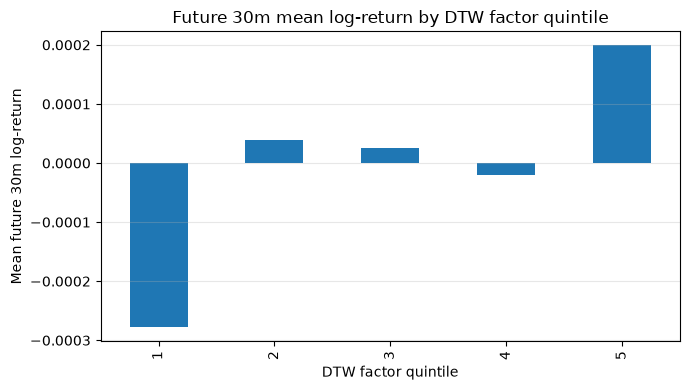

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
quintile_ret.plot(kind="bar", ax=ax)
ax.set_title("Future 30m mean log-return by DTW factor quintile")
ax.set_xlabel("DTW factor quintile")
ax.set_ylabel("Mean future 30m log-return")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

**Findings:** On this mixed-event top-k run, 2,105/2,355 games are scored,
with Pearson IC 0.0699, Spearman IC 0.0355, hit-rate 50.69%, and Q5-Q1
spread 0.000477. Event-level Pearson IC is strongest for FOMC (0.1486)
and PCE (0.0889), positive for CPI (0.0234), and negative for NFP (-0.0419).

## IC by input-series DTW factor (split by T0)

Here we treat each T0 clock as a separate DTW factor stream, e.g.
`dtw_factor_t0_08:30`, `dtw_factor_t0_09:00`, etc., and evaluate each
stream's IC metrics on its own samples.

In [ ]:
def ic_summary(df: pd.DataFrame, factor_col: str, target_col: str) -> pd.Series:
    if len(df) == 0:
        return pd.Series(
            {
                "n": 0,
                "pearson_ic": np.nan,
                "spearman_ic": np.nan,
                "hit_rate": np.nan,
                "mean_factor": np.nan,
                "mean_future_logret": np.nan,
            }
        )
    hit_rate = (
        np.sign(df[factor_col]).to_numpy() == np.sign(df[target_col]).to_numpy()
    ).mean()
    return pd.Series(
        {
            "n": int(len(df)),
            "pearson_ic": df[factor_col].corr(df[target_col], method="pearson"),
            "spearman_ic": df[factor_col].corr(df[target_col], method="spearman"),
            "hit_rate": float(hit_rate),
            "mean_factor": float(df[factor_col].mean()),
            "mean_future_logret": float(df[target_col].mean()),
        }
    )


valid["dtw_factor_name"] = "dtw_factor_t0_" + valid["clock_et"]

ic_rows = []
for (clock_et, offset_min, factor_name), g in valid.groupby(
    ["clock_et", "offset_min", "dtw_factor_name"], sort=True
):
    s = ic_summary(g, "dtw_factor", "future_logret")
    ic_rows.append(
        {
            "clock_et": clock_et,
            "offset_min": offset_min,
            "dtw_factor_name": factor_name,
            "n": int(s["n"]),
            "pearson_ic": float(s["pearson_ic"]),
            "spearman_ic": float(s["spearman_ic"]),
            "hit_rate": float(s["hit_rate"]),
            "mean_factor": float(s["mean_factor"]),
            "mean_future_logret": float(s["mean_future_logret"]),
        }
    )
ic_by_t0 = pd.DataFrame(ic_rows).sort_values("clock_et").reset_index(drop=True)

print("IC summary by T0-specific DTW factor:")
print(ic_by_t0.to_string(index=False))

IC summary by T0-specific DTW factor:
clock_et  offset_min     dtw_factor_name   n  pearson_ic  spearman_ic  hit_rate   mean_factor  mean_future_logret
   08:00         -30 dtw_factor_t0_08:00 458    0.024860     0.014692  0.500000  2.307897e-04            0.000158
   08:30           0 dtw_factor_t0_08:30 458    0.020381     0.026751  0.508734  2.564845e-07           -0.000066
   09:00          30 dtw_factor_t0_09:00 458    0.046657     0.026269  0.524017  3.860602e-05            0.000020
   09:30          60 dtw_factor_t0_09:30 458   -0.023506    -0.010562  0.493450  3.575383e-05            0.000002
   13:30         -30 dtw_factor_t0_13:30  73    0.117478     0.023664  0.383562  6.208427e-04            0.000585
   14:00           0 dtw_factor_t0_14:00  73    0.060479     0.078459  0.506849 -4.582817e-04           -0.000548
   14:30          30 dtw_factor_t0_14:30  73    0.100612     0.141645  0.671233 -1.158946e-03           -0.001174
   15:00          60 dtw_factor_t0_15:00  54   -0.

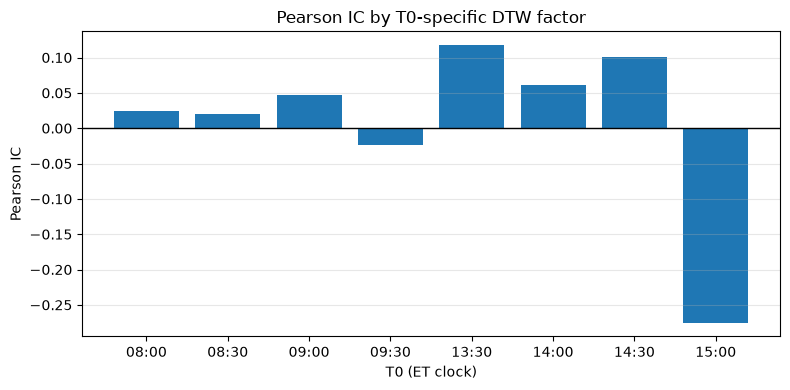

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ic_by_t0["clock_et"], ic_by_t0["pearson_ic"])
ax.set_title("Pearson IC by T0-specific DTW factor")
ax.set_xlabel("T0 (ET clock)")
ax.set_ylabel("Pearson IC")
ax.axhline(0.0, color="black", linewidth=1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

**Findings:** Splitting by T0 exposes heterogeneous factor quality. In this
run, 09:00 (Pearson IC 0.0467) and 14:30 (0.1006) are positive, while
09:30 (-0.0235) and 15:00 (-0.2751, small sample) are weak/negative. The
output table should be used directly for selecting which T0-specific DTW
factors to keep in the next modeling pass.

## T0 composition by event type and offset

To diagnose strongly negative T0 factors, we decompose each T0 stream into
its underlying `event_type × offset_min` components and compute subgroup IC.

In [ ]:
t0_component_stats = (
    valid.groupby(["clock_et", "offset_min", "event_type"], as_index=False)
    .apply(lambda g: ic_summary(g, "dtw_factor", "future_logret"), include_groups=False)
    .reset_index()
)
t0_component_stats = t0_component_stats.drop(columns=["level_3"], errors="ignore")
t0_component_stats["n"] = t0_component_stats["n"].astype(int)
t0_component_stats["t0_total_n"] = t0_component_stats.groupby("clock_et")["n"].transform("sum")
t0_component_stats["sample_share"] = t0_component_stats["n"] / t0_component_stats["t0_total_n"]
t0_component_stats = t0_component_stats.sort_values(
    ["clock_et", "n", "event_type"], ascending=[True, False, True]
).reset_index(drop=True)

print("Component breakdown for each T0 (event_type x offset):")
print(
    t0_component_stats[
        [
            "clock_et",
            "offset_min",
            "event_type",
            "n",
            "sample_share",
            "pearson_ic",
            "spearman_ic",
            "hit_rate",
            "mean_future_logret",
        ]
    ].to_string(index=False)
)

Component breakdown for each T0 (event_type x offset):
clock_et  offset_min event_type   n  sample_share  pearson_ic  spearman_ic  hit_rate  mean_future_logret
   08:00         -30        CPI 159      0.347162   -0.002737    -0.063799  0.452830            0.000226
   08:00         -30        PCE 150      0.327511   -0.023203    -0.027768  0.493333            0.000084
   08:00         -30        NFP 149      0.325328    0.110617     0.144495  0.557047            0.000160
   08:30           0        CPI 159      0.347162   -0.000297     0.017626  0.503145            0.000195
   08:30           0        PCE 150      0.327511    0.096841     0.074583  0.553333           -0.000342
   08:30           0        NFP 149      0.325328   -0.041584    -0.006164  0.469799           -0.000068
   09:00          30        CPI 159      0.347162    0.120688     0.108409  0.553459            0.000004
   09:00          30        PCE 150      0.327511    0.143062     0.046848  0.513333           -0.000069


In [ ]:
negative_t0 = ic_by_t0.loc[ic_by_t0["pearson_ic"] < 0, "clock_et"].tolist()
negative_component_stats = t0_component_stats[
    t0_component_stats["clock_et"].isin(negative_t0)
].copy()

print("\nT0 factors with negative Pearson IC:")
print(ic_by_t0.loc[ic_by_t0["pearson_ic"] < 0, ["clock_et", "offset_min", "n", "pearson_ic"]].to_string(index=False))
print("\nTheir event_type x offset composition:")
print(
    negative_component_stats[
        [
            "clock_et",
            "offset_min",
            "event_type",
            "n",
            "sample_share",
            "pearson_ic",
            "mean_future_logret",
        ]
    ].to_string(index=False)
)


T0 factors with negative Pearson IC:
clock_et  offset_min   n  pearson_ic
   09:30          60 458   -0.023506
   15:00          60  54   -0.275096

Their event_type x offset composition:
clock_et  offset_min event_type   n  sample_share  pearson_ic  mean_future_logret
   09:30          60        CPI 159      0.347162   -0.076355           -0.000258
   09:30          60        PCE 150      0.327511    0.040539            0.000194
   09:30          60        NFP 149      0.325328   -0.012371            0.000087
   15:00          60       FOMC  54      1.000000   -0.275096            0.000314


**Findings:** The negative T0 factors are `09:30` (IC -0.0235, n=458) and
`15:00` (IC -0.2751, n=54). For `09:30`, the largest negative contributor is
the CPI slice (`offset=+60`, n=159, subgroup IC -0.0764), while the PCE slice
is mildly positive. `15:00` is purely FOMC (`offset=+60`) and remains
negative in this run, suggesting that late post-FOMC behavior should be
treated as a separate regime.

## Notes for next iteration

- Add significance-threshold gating (distance threshold / permutation null)
  after baseline top-k results are established.
- Compare mixed-event matching versus strict event-specific matching.
- Add a simple momentum baseline on the same game universe.